<h1>Содержание<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Подготовка" data-toc-modified-id="Подготовка-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Подготовка</a></span><ul class="toc-item"><li><span><a href="#Загрузка-библиотек" data-toc-modified-id="Загрузка-библиотек-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>Загрузка библиотек</a></span></li><li><span><a href="#Загрузка-данных" data-toc-modified-id="Загрузка-данных-1.2"><span class="toc-item-num">1.2&nbsp;&nbsp;</span>Загрузка данных</a></span></li><li><span><a href="#EDA" data-toc-modified-id="EDA-1.3"><span class="toc-item-num">1.3&nbsp;&nbsp;</span>EDA</a></span></li></ul></li><li><span><a href="#Обучение" data-toc-modified-id="Обучение-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Обучение</a></span><ul class="toc-item"><li><span><a href="#Подготовка" data-toc-modified-id="Подготовка-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>Подготовка</a></span></li><li><span><a href="#Кросс-валидация" data-toc-modified-id="Кросс-валидация-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>Кросс-валидация</a></span></li><li><span><a href="#Тестирование" data-toc-modified-id="Тестирование-2.3"><span class="toc-item-num">2.3&nbsp;&nbsp;</span>Тестирование</a></span></li></ul></li><li><span><a href="#Выводы" data-toc-modified-id="Выводы-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Выводы</a></span></li></ul></div>

# Проект для «Викишоп»

__Описание проекта:__ Интернет-магазин «Викишоп» запускает новый сервис. Теперь пользователи могут редактировать и дополнять описания товаров, как в вики-сообществах: клиенты предлагают свои правки и комментируют изменения других. Магазину нужен инструмент, который будет искать токсичные комментарии и отправлять их на модерацию. 

__Цель исследования:__ 
- Обучить модель классификации комментариев на позитивные и негативные.

Постройте модель со значением метрики качества *F1* не меньше 0.75.

## Подготовка

### Загрузка библиотек

Установка необходимых библиотек:

In [1]:
!pip install -Uq seaborn pandas numpy==2.3 torch scikit-learn wordcloud spacy

In [2]:
import math
import torch
import transformers
import nltk
import spacy

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from wordcloud import WordCloud

from nltk.corpus import stopwords as nltk_stopwords

from tqdm import notebook

from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, TfidfTransformer

from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score, precision_recall_curve, confusion_matrix, PrecisionRecallDisplay, roc_curve, RocCurveDisplay

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

In [3]:
sns.set_style('darkgrid')

In [4]:
plt.style.use('ggplot')

In [5]:
def short_summary(dataframe):
	print('\033[1mКраткая информация:\033[0m\n')
	dataframe.info()
	print('\n\n\033[1mРазмерность:\033[0m', dataframe.shape, end='\n\n\n')
	print('\033[1m5 случайных строк датафрейма:\033[0m\n')
	display(dataframe.sample(5))

### Загрузка данных

In [ ]:
try:
	start_data = pd.read_csv('toxic_comments.csv', index_col=[0])
except:
	start_data = pd.read_csv('/datasets/toxic_comments.csv', index_col=[0])

In [7]:
short_summary(start_data)

Краткая информация:

<class 'pandas.DataFrame'>
Index: 159292 entries, 0 to 159450
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   text    159292 non-null  str  
 1   toxic   159292 non-null  int64
dtypes: int64(1), str(1)
memory usage: 63.5 MB


Размерность: (159292, 2)


5 случайных строк датафрейма:



,text,toxic
70935,"""\nGlobal warming\nHey Ross, I reverted your e...",0
35666,"""\n\n 75.3.64.232 has pictoral brown eyes then...",1
118383,"""""""you suck monkey butts"""" said George Washing...",1
127033,In Bhagavata Purana he's called only by the na...,0
70098,"""\n\n A last note \n\nAlthough I strongly disa...",0


### EDA

В данных отсутствуют пропуски:

In [8]:
start_data.isna().sum()

text     0
toxic    0
dtype: int64

Так же наблюдается дисбаланс целевого признака:

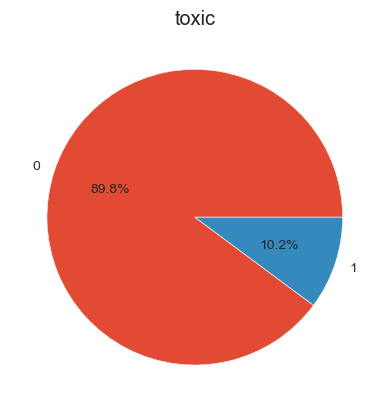

In [9]:
start_data.groupby(by='toxic').agg({'toxic': 'count'}).plot(kind='pie',
											y='toxic',
											autopct='%1.1f%%',
											title='toxic',
											legend=False,
										   )
	
plt.axis('off')
plt.show()

In [10]:
text = ' '.join(start_data['text'].dropna())

In [11]:
wc = WordCloud().generate(text)

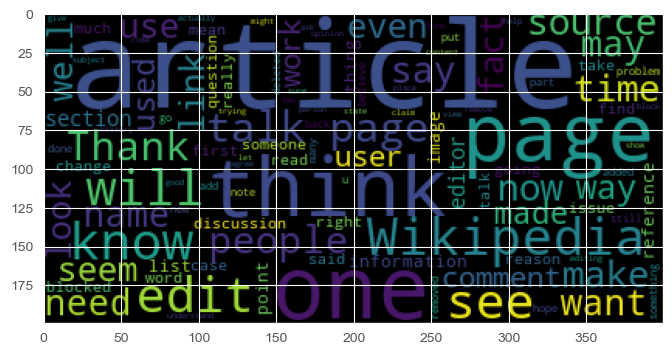

In [12]:
plt.figure(figsize=(8,8))

plt.imshow(wc)

plt.show()

В данных чаще встречаются достаточно нейтральные слова, что совпадает с информацией о дисбалансе в сторону нетоксичных комментариев.

In [13]:
wc_non_toxic = WordCloud().generate(' '.join(start_data.loc[start_data['toxic'] == 0]['text'].dropna()))

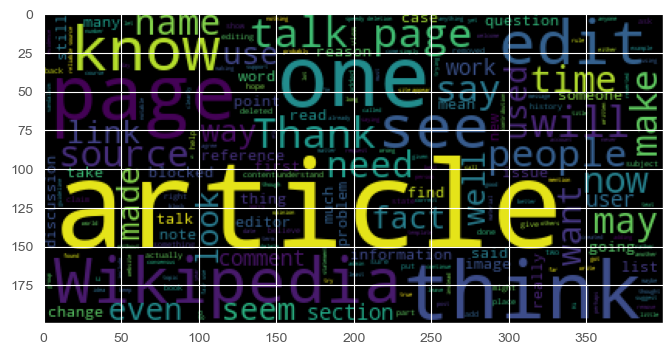

In [14]:
plt.figure(figsize=(8,8))

plt.imshow(wc_non_toxic)

plt.show()

Слова, чаще всего встречающиеся в токсичных комментариях:

In [15]:
wc_toxic = WordCloud().generate(' '.join(start_data.loc[start_data['toxic'] == 1]['text'].dropna()))

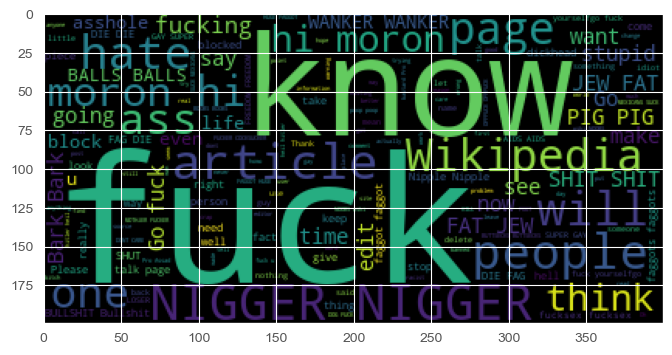

In [16]:
plt.figure(figsize=(8,8))

plt.imshow(wc_toxic)

plt.show()

__Вывод:__ были загружены предоставленные заказчиком данные; информация приведена в корректных типах данных; обнаружен дисбаланс классов, что требует стратификации при разбиении выборок.

## Обучение

### Подготовка

In [17]:
RANDOM_STATE = 42

In [18]:
def data_split(data, target='toxic', RANDOM_STATE = RANDOM_STATE, TEST_SIZE = 0.25):
	X_train, X_test, y_train, y_test = train_test_split(
		data.drop(target, axis=1),
		data[target],
		test_size = TEST_SIZE, 
		random_state = RANDOM_STATE,
        stratify=data[target]
	)
	return X_train, X_test, y_train, y_test

Для лематизации и очистки от неинформативных слов и символов используем функционал библиотеки SpaCy.

In [19]:
!python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ----- ---------------------------------- 1.8/12.8 MB 24.0 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 62.4 MB/s  0:00:00
[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [20]:
nlp = spacy.load('en_core_web_sm')

In [21]:
data = start_data.copy()

In [22]:
%%time
lemms = []
lemm_str = []

for doc in nlp.pipe(data['text'], batch_size=5000):
    lemm_str = []
    for token in doc:
        if token.is_alpha and not token.is_stop:
            lemm_str.append(token.lemma_.lower())
    lemm_str = ' '.join(lemm_str)
    lemms.append(lemm_str)

CPU times: total: 31min 12s
Wall time: 31min 15s


In [23]:
data['text'] = lemms

Разбиение данных на выборки:

In [24]:
X_train, X_test, y_train, y_test = data_split(data)

### Кросс-валидация

Для решения задачи классификации выполним кросс-валидацию с подбором наилучших гиперпараметров среди таких моделей:

- Логистическая регрессия;
- Метод опорных векторов;
- Дерево принятия решений.

In [25]:
def summaries_classification(y, y_pred, mod_name='Название модели'):
	chars = [
		accuracy_score(y, y_pred),
		recall_score(y, y_pred, pos_label=1),
		precision_score(y, y_pred, pos_label=1),
		f1_score(y, y_pred, pos_label=1)
	]
			
	return pd.DataFrame(
		data=chars,
		index=['Accuracy(Точность)', 'Recall(Полнота)', 'Precision(Прецизионность)', 'F1-score(F1-мера)'],
		columns=[mod_name])

Пайплайн:

In [26]:
pipe = Pipeline([
    ('vect', CountVectorizer(ngram_range=(1,3), min_df=20)),
    ('tfidf', TfidfTransformer()),
    ('models', LogisticRegression())
])

In [27]:
param_grid = [
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 10, 4),
        'models__max_features': range(2, 10, 4),
    },
    
    {
        'models': [LinearSVC(random_state=RANDOM_STATE)],
        'models__C': np.logspace(-4, 2, 10)
    },

    {
        'models': [LogisticRegression(random_state=RANDOM_STATE, solver='liblinear')],
        'models__C':[0.01, 0.1, 0.5, 1, 10],
        'models__l1_ratio':[1, 0]
    }
]

In [28]:
grid_search = GridSearchCV(
    pipe, 
    param_grid, 
    scoring='f1',
    n_jobs=-1
)

Проводим кросс-валидацию:

In [29]:
%%time
grid_search.fit(X_train['text'], y_train)

CPU times: total: 16.4 s
Wall time: 2min 56s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'models': [DecisionTreeC...ndom_state=42)], 'models__max_depth': range(2, 10, 4), 'models__max_features': range(2, 10, 4)}, {'models': [LinearSVC(random_state=42)], 'models__C': array([1.0000...00000000e+02])}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here...

Метрика на кросс-валидации:

In [30]:
grid_search.best_score_

np.float64(0.770716369586615)

Метрика лучшей модели:

In [31]:
summaries_classification(y_train, grid_search.predict(X_train['text']), mod_name='LogisticRegression')

,LogisticRegression
Accuracy(Точность),0.962986
Recall(Полнота),0.699753
Precision(Прецизионность),0.916199
F1-score(F1-мера),0.793480


__Вывод:__ в результате кросс-валидации определена лучшая модель со следующими параметрами: логистическая регрессия, l1-регуляризация, величина С=1.

### Тестирование

Получим предсказания на тесте:

In [32]:
y_test_preds = grid_search.predict(X_test['text'])

Значения метрик на тесте:

In [33]:
summaries_classification(y_test, y_test_preds, mod_name='Логистическая регрессия, тестовая выборка')

,"Логистическая регрессия, тестовая выборка"
Accuracy(Точность),0.959019
Recall(Полнота),0.675729
Precision(Прецизионность),0.895219
F1-score(F1-мера),0.770141


Видно, что метрики на тесте незначительно упали, однако находятся в пределах допускаемого согласно ТЗ. Таким образом, переобучение не наблюдается

Матрица ошибок для модели:

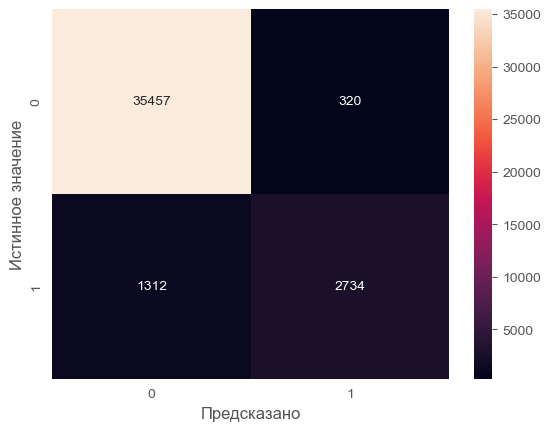

In [34]:
sns.heatmap(confusion_matrix(y_test, y_test_preds), annot=True, fmt='d')

plt.ylabel('Истинное значение')
plt.xlabel('Предсказано')
plt.show()

Из матрицы ошибок видно, что хоть и большинство меток классов проставлены моделью верно, имеется тенденция - модель чаще "пропускает" токсичные комментарии, чем помечает токсичными обычные (ошибка второго рода).

Модель хорошо разделяет комментарии на классы: виден быстрый рост уровня TPR при относительно невысоких ложных метках; однако затем наблюдется резкий рост FPR - хотя большинство слов определено верно, для максимального точно предсказания модель вынуждена проставлять метки положительного класса и увеличивать ошибку.

In [35]:
preds = grid_search.predict_proba(X_test['text'])[:,1]

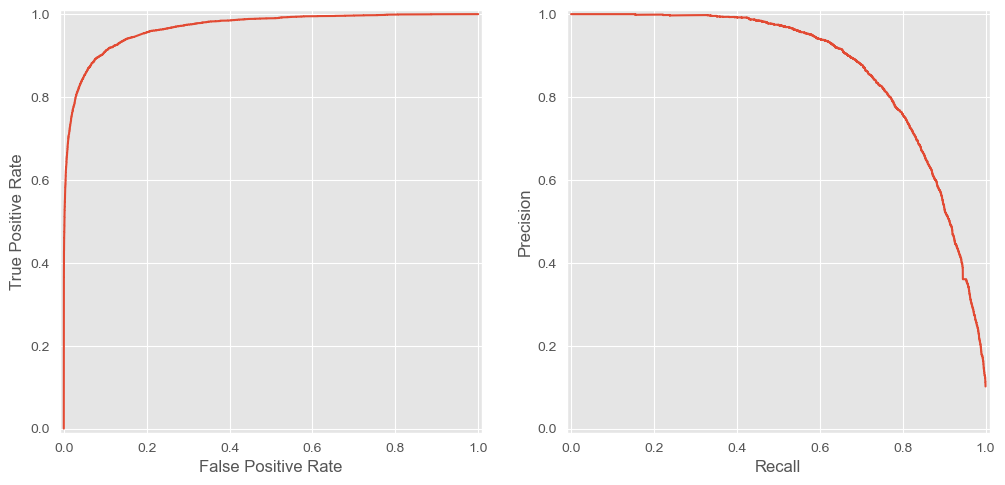

In [36]:
precision, recall, _ = precision_recall_curve(y_test, preds)
pr_display = PrecisionRecallDisplay(precision=precision, recall=recall)

fpr, tpr, _ = roc_curve(y_test, preds)
roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))

roc_display.plot(ax=ax1)
pr_display.plot(ax=ax2)

plt.show()

Так же наблюдаем высокие совместные значения прецизионности и полноты - модель качественно разделяет большинство слов, но при достижении определенного порога повышение полноты требует снижения прецизионности.

Данные наблюдения говорят о наличии небольшой группы слов, которые модель затрудняется отнести к правильному классу.

Спиок подобных строк

In [37]:
X_t, X_tt, y_t, y_tt = data_split(start_data)

In [38]:
value_stat = pd.DataFrame({
    'sentence': X_tt['text'],
    'weight': preds
             }
            ).sort_values(by='weight', ascending=True).head(10)

In [39]:
pd.set_option('max_colwidth', 180)
value_stat

,sentence,weight
114577,"""\n Just like Heaven (song)\nWesley, how's it coming? Separating the FACs that are waiting for Raul, or use non-reliable sources, this is now our longest-running FAC. Can ind...",0.000052
48648,"Your note\nAw, shucks! Thanks! delldot | talk",0.000070
144281,"""\nThe thing is, it isn't an """"issue"""". It's DRM. The section should be DRM, then state the points and counterpoints. talk """,0.000071
54227,"""\n\n Jennifer Ann Crecente \n\nHi, you chimed in during the discussion for an AfD for this article a while back. The article was re-created after two pieces of legislation wer...",0.000074
2668,"""\n\n Armour \n\nA source that is not listed as an inline citation in an article is not a reference, it does not point to any specific text in the article. It is """"further read...",0.000075
47381,Thank you very much! ),0.000089
53943,"Thank you, I will do my best.81.103.121.144",0.000089
15106,"Thanks, I have just did it )",0.000089
13862,"Thank you, Mendaliv.",0.000089
12630,"Thanks, dude.70.76.85.36",0.000089


In [40]:
pd.reset_option('all')

C:\Users\Tomat\AppData\Local\Temp\ipykernel_16260\2786130087.py:1: Pandas4Warning: 'future.no_silent_downcasting' is deprecated, please refrain from using it.
  pd.reset_option('all')
C:\Users\Tomat\AppData\Local\Temp\ipykernel_16260\2786130087.py:1: Pandas4Warning: The 'mode.copy_on_write' option is deprecated. Copy-on-Write can no longer be disabled (it is always enabled with pandas >= 3.0), and setting the option has no impact. This option will be removed in pandas 4.0.
  pd.reset_option('all')


Скорее всего в данном случае решающим фактором является неточная разметка данных - содержимое большинства строк вполне можно истолковать как токсичное/нетоксичное.

Рассмотрим какие слова являются решающими при определении токсичности:

In [41]:
words_stat = pd.DataFrame({
    'word': grid_search.best_estimator_.named_steps['vect'].get_feature_names_out(),
    'weight': grid_search.best_estimator_.named_steps['models'].coef_[0]
             }
            )

10 наиболее токсичных слов ожидаемо относятся к обсценной лексике

In [42]:
words_stat.sort_values(by=['weight'], ascending=False).head(10).T

,7649,7671,1732,2319,17271,9087,6928,2709,1712,18552
word,fuck,fucking,asshole,bitch,shit,idiot,faggot,bullshit,ass,suck
weight,38.147613,25.753053,20.07446,19.174606,19.109072,18.706947,16.429613,16.019197,15.989877,15.845387


10 наименее токсичных слов при этом являются наиболее нейтральными (кроме thank). Так же заметная разница в асболютных значениях - токсичные слова имеют больший вес и сильнее выделяются моделью

In [43]:
words_stat.sort_values(by=['weight'], ascending=True).head(10).T

,19297,11800,18324,10481,15444,12120,16974,9745,11292,4134
word,thank,merge,stop continue,lead,reach,move,section,interesting,luke,continue block edit
weight,-6.148545,-4.653878,-4.573525,-4.110534,-3.916788,-3.828764,-3.72483,-3.661873,-3.655349,-3.596177


## Выводы

В ходе работы были загружены данные от заказчика по комментариям в интернете. Полученные данны были проанализированы, закодированы и сформированы в корпус текстов для последующего обучения моделей.

Для обучения использовались следующие модели:
- Логистическая регрессия;
- Метод опорных векторов;
- Дерево принятия решений.

Для оценки выбла выполнена кросс-валидация с подбором гиперпараметров и рассмотрением разных вариантов n-грам.

В ходе обучения лучше была признана модель логистической регрессии. С помощью этой модели были выполнены предсказания на тестовых данных, которые показали так же высокие значения.

В ходе анализа были рассмотрены такие критерии: матрица ошибок, кривая ROC, зависимость Precision-Recall; были проанализированы слова, рассматривая которые модель наиболее и наименее вероятно ставит метку токсичности. Дополнительно были рассмотрены сообщения, метку которым модель ставить затруднялась.

Таким образом, в данной работе была определена лучшая модель классификации тональности текстов с метрикой f1=0,77 на тестовой выборке.